In [1]:
import os
os.environ['USE_TF'] = '0' 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk
import string
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from transformers import pipeline
import torch
from newsapi import NewsApiClient
import yfinance as yf
from datetime import datetime, timedelta

/Users/cagcanarpa/dl_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Step 1

1.1.LOADING DATA

In [2]:
df = pd.read_csv('data.csv', encoding='latin-1', header=None, names=['sentiment', 'text'])

In [3]:
print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (4846, 2)

First 3 rows:


,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...


1.2.BASIC DATA INFO

In [4]:
print("Null values:\n", df.isnull().sum())
print("Duplicated rows:", df.duplicated().sum())
print("Duplicate texts only:", df.duplicated(subset=['text']).sum())
print("Sentiment types:", df['sentiment'].unique())

Null values:
 sentiment    0
text         0
dtype: int64
Duplicated rows: 6
Duplicate texts only: 8
Sentiment types: ['neutral' 'negative' 'positive']


In [5]:
# Remove
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4838, 2)


1.3.CLASS DISTRIBUTION

In [6]:
counts = df['sentiment'].value_counts()
print(counts)

sentiment
neutral     2872
positive    1362
negative     604
Name: count, dtype: int64


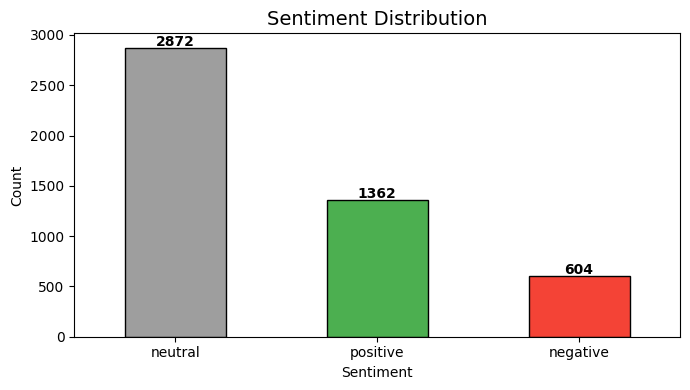

In [7]:
plt.figure(figsize=(7, 4))
colors = ['#9E9E9E', '#4CAF50', '#F44336']
counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
negative_rate = round(counts['negative']/len(df)*100,1)
negative_rate

12.5

In [9]:
print(f"\n⚠️ Negative is only {negative_rate}% of data — we'll need SMOTE later!")


⚠️ Negative is only 12.5% of data — we'll need SMOTE later!


1.4.TEXT LENGTH ANALYSIS

           text_length  word_count
sentiment                         
negative         125.8        23.9
neutral          125.0        22.2
positive         135.6        24.7


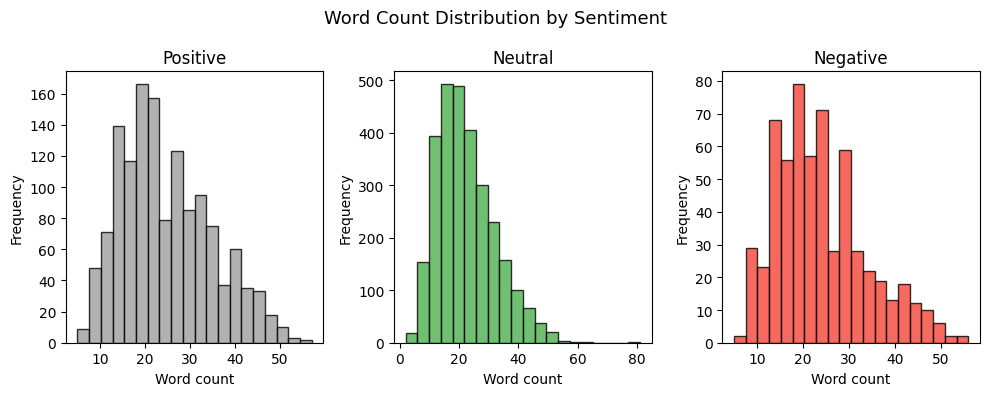

In [10]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(df.groupby('sentiment')[['text_length', 'word_count']].mean().round(1))

plt.figure(figsize=(10, 4))
for i, sentiment in enumerate(['positive', 'neutral', 'negative']):
    plt.subplot(1, 3, i+1)
    subset = df[df['sentiment'] == sentiment]['word_count']
    plt.hist(subset, bins=20, color=colors[i], edgecolor='black', alpha=0.8)
    plt.title(f'{sentiment.capitalize()}')
    plt.xlabel('Word count')
    plt.ylabel('Frequency')
plt.suptitle('Word Count Distribution by Sentiment', fontsize=13)
plt.tight_layout()
plt.show()

1.5.MOST COMMON WORDS PER CLASS

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cagcanarpa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


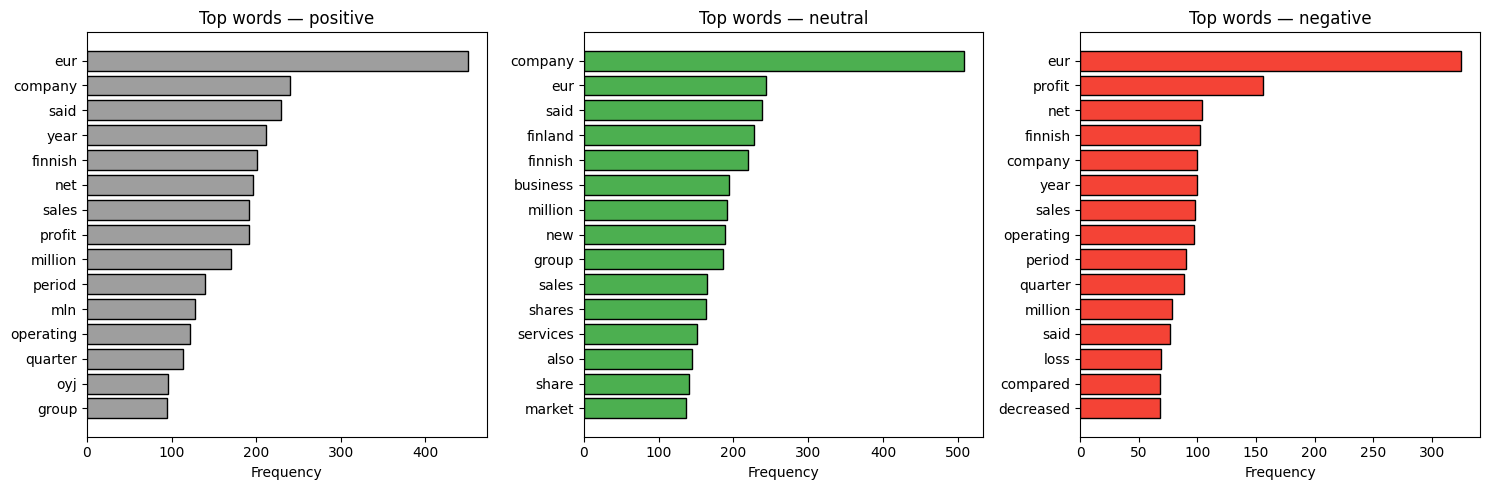

In [11]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
        words.extend([w for w in tokens if w not in stop_words])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (sentiment, color) in zip(axes, zip(['positive', 'neutral', 'negative'], colors)):
    top = get_top_words(df[df['sentiment'] == sentiment]['text'])
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top words — {sentiment}', fontsize=12)
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

1.6.SUMMARY

In [12]:
print("=" * 45)
print("EDA SUMMARY")
print("=" * 45)
print(f"Total samples:     {len(df)}")
print(f"Positive:          {counts['positive']} ({counts['positive']/len(df)*100:.1f}%)")
print(f"Neutral:           {counts['neutral']} ({counts['neutral']/len(df)*100:.1f}%)")
print(f"Negative:          {counts['negative']} ({counts['negative']/len(df)*100:.1f}%)")
print(f"Avg word count:    {df['word_count'].mean():.1f}")
print(f"Duplicates:        {df.duplicated().sum()}")
print("\n📌 Key findings:")
print("  - Class imbalance: negative is underrepresented → use SMOTE or class_weight")
print("  - Short texts: avg ~20 words → FinBERT handles this well")
print("  - No missing values → clean dataset, ready for modeling")

EDA SUMMARY
Total samples:     4838
Positive:          1362 (28.2%)
Neutral:           2872 (59.4%)
Negative:          604 (12.5%)
Avg word count:    23.1
Duplicates:        0

📌 Key findings:
  - Class imbalance: negative is underrepresented → use SMOTE or class_weight
  - Short texts: avg ~20 words → FinBERT handles this well
  - No missing values → clean dataset, ready for modeling


## Step 2

2.1.CLEANING

In [13]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')


def clean(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, ' ')  # Remove Punctuation
    lowercased = text.lower() # Lower Case
    tokenized = word_tokenize(lowercased) # Tokenize
    words_only = [word for word in tokenized if word.isalpha()] # Remove numbers
    stop_words = set(stopwords.words('english')) # Make stopword list
    without_stopwords = [word for word in words_only if word not in stop_words] # Remove Stop Words
    lemma = WordNetLemmatizer() # Initiate Lemmatizer
    lemmatized = [lemma.lemmatize(word) for word in without_stopwords]  # Lemmatize
    cleaned = ' '.join(lemmatized)  # Join back to a string
    return cleaned

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/cagcanarpa/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/cagcanarpa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cagcanarpa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/cagcanarpa/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [14]:
# Keep original for FinBERT
df['text_raw'] = df['text']

# Cleaned version for VADER + traditional ML
df['text_clean'] = df['text'].apply(clean)

df.head()

,sentiment,text,text_length,word_count,text_raw,text_clean
0,neutral,"According to Gran , the company has no plans t...",127,25,"According to Gran , the company has no plans t...",according gran company plan move production ru...
1,neutral,Technopolis plans to develop in stages an area...,190,31,Technopolis plans to develop in stages an area...,technopolis plan develop stage area less squar...
2,negative,The international electronic industry company ...,228,36,The international electronic industry company ...,international electronic industry company elco...
3,positive,With the new production plant the company woul...,206,33,With the new production plant the company woul...,new production plant company would increase ca...
4,positive,According to the company 's updated strategy f...,203,41,According to the company 's updated strategy f...,according company updated strategy year baswar...


2.2.SANITY CHECK

In [15]:
empty = df['text_clean'].str.strip().eq('').sum()
print(f"Empty rows after cleaning: {empty}")

Empty rows after cleaning: 1


In [16]:
if empty > 0:
    df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
    print(f"Dropped {empty} empty rows. New shape: {df.shape}")

# Check lengths again after cleaning
df['clean_word_count'] = df['text_clean'].str.split().str.len()
print("\nAvg word count after cleaning:")
print(df.groupby('sentiment')['clean_word_count'].mean().round(1))

Dropped 1 empty rows. New shape: (4837, 6)

Avg word count after cleaning:
sentiment
negative    11.8
neutral     11.8
positive    12.9
Name: clean_word_count, dtype: float64


2.3.ENCODE TARGET

In [17]:
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
df['label'] = df['sentiment'].map(label_map)

df.head()

,sentiment,text,text_length,word_count,text_raw,text_clean,clean_word_count,label
0,neutral,"According to Gran , the company has no plans t...",127,25,"According to Gran , the company has no plans t...",according gran company plan move production ru...,10,1
1,neutral,Technopolis plans to develop in stages an area...,190,31,Technopolis plans to develop in stages an area...,technopolis plan develop stage area less squar...,17,1
2,negative,The international electronic industry company ...,228,36,The international electronic industry company ...,international electronic industry company elco...,21,0
3,positive,With the new production plant the company woul...,206,33,With the new production plant the company woul...,new production plant company would increase ca...,20,2
4,positive,According to the company 's updated strategy f...,203,41,According to the company 's updated strategy f...,according company updated strategy year baswar...,18,2


In [18]:
# save the data 
df.to_csv('data_cleaned.csv', index=False)
print("✅ Saved as data_cleaned.csv")

✅ Saved as data_cleaned.csv


## Step 3

In [19]:
# TRAIN/TEST SPLIT
# Stratified = keeps class proportions in both splits
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']   # class imbalance
)

X_test_raw = df.loc[X_test.index, 'text_raw']

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print("\nClass distribution in test set:")
print(y_test.value_counts())

Train size: 3869 | Test size: 968

Class distribution in test set:
label
1    574
2    273
0    121
Name: count, dtype: int64


In [20]:
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    compound = analyzer.polarity_scores(text)['compound']
    if compound >= 0.05:
        return 2   # positive
    elif compound <= -0.05:
        return 0   # negative
    else:
        return 1   # neutral

y_pred_vader = X_test.apply(vader_predict)

print("Classification Report (Test Set):")
print(classification_report(
    y_test,
    y_pred_vader,
    target_names=['negative', 'neutral', 'positive']
))

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.45      0.31      0.36       121
     neutral       0.72      0.49      0.58       574
    positive       0.38      0.68      0.49       273

    accuracy                           0.52       968
   macro avg       0.51      0.49      0.48       968
weighted avg       0.59      0.52      0.53       968



In [21]:
# CROSS VALIDATION
from sklearn.base import BaseEstimator, ClassifierMixin

class VADERClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return [vader_predict(text) for text in X]

vader_clf = VADERClassifier()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    vader_clf,
    df['text_clean'],
    df['label'],
    cv=cv,
    scoring='f1_weighted'
)

print("Cross-Validation F1 scores:", cv_scores.round(3))
print(f"Mean F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Cross-Validation F1 scores: [0.545 0.551 0.528 0.543 0.549]
Mean F1: 0.543 (+/- 0.008)


In [22]:
# ACTUAL vs PREDICTED SAMPLE
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

comparison = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.map(label_names).values,
    'predicted': y_pred_vader.map(label_names).values
})
comparison['correct'] = comparison['actual'] == comparison['predicted']

print(comparison.sample(10, random_state=42).to_string())
print(f"\nCorrect: {comparison['correct'].sum()} / {len(comparison)}")

                                                                                                                             text    actual predicted  correct
575                                           finnish meat company atrium longer promise sufficient amount domestic beef customer  negative  positive    False
259                                                                                  total value project valued sek eur bn usd bn   neutral  positive    False
388                                               according shipping company viking line eu decision significant financial impact   neutral  positive    False
495                                                               building home improvement trade sale decreased totalling eur mn  negative  positive    False
70   remote phone management demonstrates sysopen digia unique end end offering operator handset manufacturer enterprise customer   neutral   neutral     True
904                                  contract 

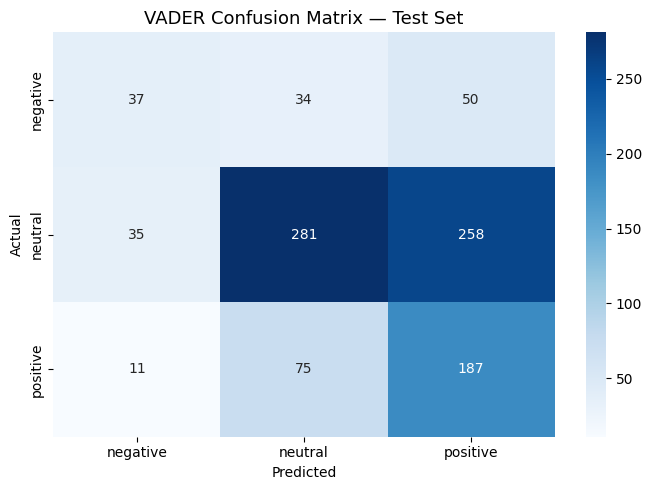

In [23]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_vader)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('VADER Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [24]:
baseline_results = {
    'model': 'VADER',
    'accuracy': accuracy_score(y_test, y_pred_vader),
    'f1_weighted': f1_score(y_test, y_pred_vader, average='weighted'),
    'cv_mean_f1': cv_scores.mean(),
    'cv_std_f1': cv_scores.std()
}

print("\n📊 BASELINE RESULTS (for comparison with FinBERT)")
print("=" * 45)
for k, v in baseline_results.items():
    if k != 'model':
        print(f"{k:20s}: {v:.3f}")


📊 BASELINE RESULTS (for comparison with FinBERT)
accuracy            : 0.522
f1_weighted         : 0.528
cv_mean_f1          : 0.543
cv_std_f1           : 0.008


## Step 4

In [25]:
# LOAD MODEL
print("Loading FinBERT...")
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    device=0 if torch.cuda.is_available() else -1  # GPU if available
)
print("✅ Model loaded!")

Loading FinBERT...


Device set to use cpu


✅ Model loaded!


In [26]:
# PREDICT ON TEST SET 
def finbert_predict(text):
    result = finbert(text[:512])[0]
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    return label_map[result['label']]

print("Running FinBERT on test set")
y_pred_finbert = X_test_raw.apply(finbert_predict)

Running FinBERT on test set


In [27]:
# ACTUAL vs PREDICTED
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

comparison_fb = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.map(label_names).values,
    'predicted': y_pred_finbert.map(label_names).values
})
comparison_fb['correct'] = comparison_fb['actual'] == comparison_fb['predicted']
print(comparison_fb.sample(10, random_state=42).to_string())

                                                                                                                             text    actual predicted  correct
575                                           finnish meat company atrium longer promise sufficient amount domestic beef customer  negative   neutral    False
259                                                                                  total value project valued sek eur bn usd bn   neutral   neutral     True
388                                               according shipping company viking line eu decision significant financial impact   neutral  negative    False
495                                                               building home improvement trade sale decreased totalling eur mn  negative  negative     True
70   remote phone management demonstrates sysopen digia unique end end offering operator handset manufacturer enterprise customer   neutral  positive    False
904                                  contract 

Classification Report (FinBERT — Test Set):
              precision    recall  f1-score   support

    negative       0.79      0.97      0.87       121
     neutral       0.95      0.84      0.90       574
    positive       0.80      0.91      0.85       273

    accuracy                           0.88       968
   macro avg       0.85      0.91      0.87       968
weighted avg       0.89      0.88      0.88       968



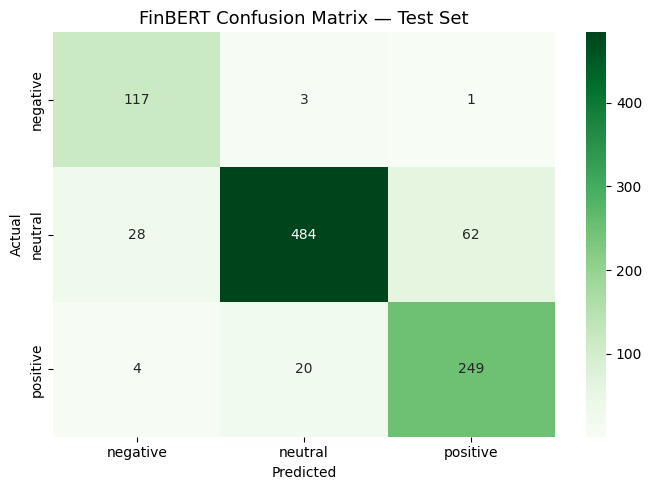

In [28]:
print("Classification Report (FinBERT — Test Set):")
print(classification_report(
    y_test,
    y_pred_finbert,
    target_names=['negative', 'neutral', 'positive']
))

cm = confusion_matrix(y_test, y_pred_finbert)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('FinBERT Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [29]:
# COMPARE VADER vs FINBERT
finbert_results = {
    'model': 'FinBERT',
    'accuracy': accuracy_score(y_test, y_pred_finbert),
    'f1_weighted': f1_score(y_test, y_pred_finbert, average='weighted'),
}

print("\n📊 MODEL COMPARISON")
print("=" * 40)
print(f"{'Metric':<20} {'VADER':>8} {'FinBERT':>8}")
print("-" * 40)
for metric in ['accuracy', 'f1_weighted']:
    v = baseline_results[metric]
    f = finbert_results[metric]
    winner = '✅' if f > v else '⚠️'
    print(f"{metric:<20} {v:>8.3f} {f:>8.3f} {winner}")


📊 MODEL COMPARISON
Metric                  VADER  FinBERT
----------------------------------------
accuracy                0.522    0.878 ✅
f1_weighted             0.528    0.879 ✅


## Step 5 — Connect with Stock Trends

In [30]:
newsapi = NewsApiClient(api_key='ef5661d3b8b3425a93181ad9c6d303d7')

def get_news(ticker, company_name, days=30):
    from_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')
    
    articles = newsapi.get_everything(
        q=company_name,
        from_param=from_date,
        language='en',
        sort_by='publishedAt'
    )
    
    news_df = pd.DataFrame([{
        'date': a['publishedAt'][:10],
        'title': a['title'],
        'description': a['description']
    } for a in articles['articles'] if a['description']])
    
    news_df['date'] = pd.to_datetime(news_df['date'])
    return news_df

In [31]:
# APPLY FINBERT TO REAL NEWS
def analyze_news_sentiment(news_df):
    news_df['text'] = news_df['title'] + '. ' + news_df['description'].fillna('')
    news_df['sentiment_label'] = news_df['text'].apply(
        lambda x: finbert(x[:512])[0]['label']
    )
    news_df['sentiment_score'] = news_df['text'].apply(
        lambda x: finbert(x[:512])[0]['score'] * 
        (1 if finbert(x[:512])[0]['label'] == 'positive' else -1)
    )
    
    # Daily average sentiment
    daily = news_df.groupby('date')['sentiment_score'].mean().reset_index()
    daily.columns = ['date', 'avg_sentiment']
    return daily

In [32]:
# GET STOCK PRICES
def get_stock_prices(ticker, days=30):
    stock = yf.Ticker(ticker)
    hist = stock.history(period=f'{days}d')[['Close']].reset_index()
    hist.columns = ['date', 'price']
    hist['date'] = pd.to_datetime(hist['date']).dt.tz_localize(None).dt.normalize()
    hist['price_change_pct'] = hist['price'].pct_change() * 100
    return hist

In [33]:
# MERGE & VISUALIZE 
def plot_sentiment_vs_price(ticker, company_name, days=30):
    print(f"Fetching news for {company_name}...")
    news_df = get_news(ticker, company_name, days)
    daily_sentiment = analyze_news_sentiment(news_df)
    
    prices = get_stock_prices(ticker, days)
    
    # Merge on date
    merged = pd.merge(prices, daily_sentiment, on='date', how='left')
    merged['avg_sentiment'] = merged['avg_sentiment'].fillna(0)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Stock price
    ax1.plot(merged['date'], merged['price'], color='#2196F3', linewidth=2)
    ax1.set_ylabel('Stock Price ($)')
    ax1.set_title(f'{company_name} ({ticker}) — Price vs News Sentiment', fontsize=14)
    ax1.grid(alpha=0.3)
    
    # Sentiment
    colors_bar = ['#4CAF50' if x > 0 else '#F44336' for x in merged['avg_sentiment']]
    ax2.bar(merged['date'], merged['avg_sentiment'], color=colors_bar, alpha=0.7)
    ax2.axhline(y=0, color='black', linewidth=0.8)
    ax2.set_ylabel('Avg Sentiment Score')
    ax2.set_xlabel('Date')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation
    corr = merged[['price_change_pct', 'avg_sentiment']].dropna().corr()
    print(f"\n📊 Correlation (price change vs sentiment): {corr.iloc[0,1]:.3f}")
    
    return merged

Fetching news for Apple...


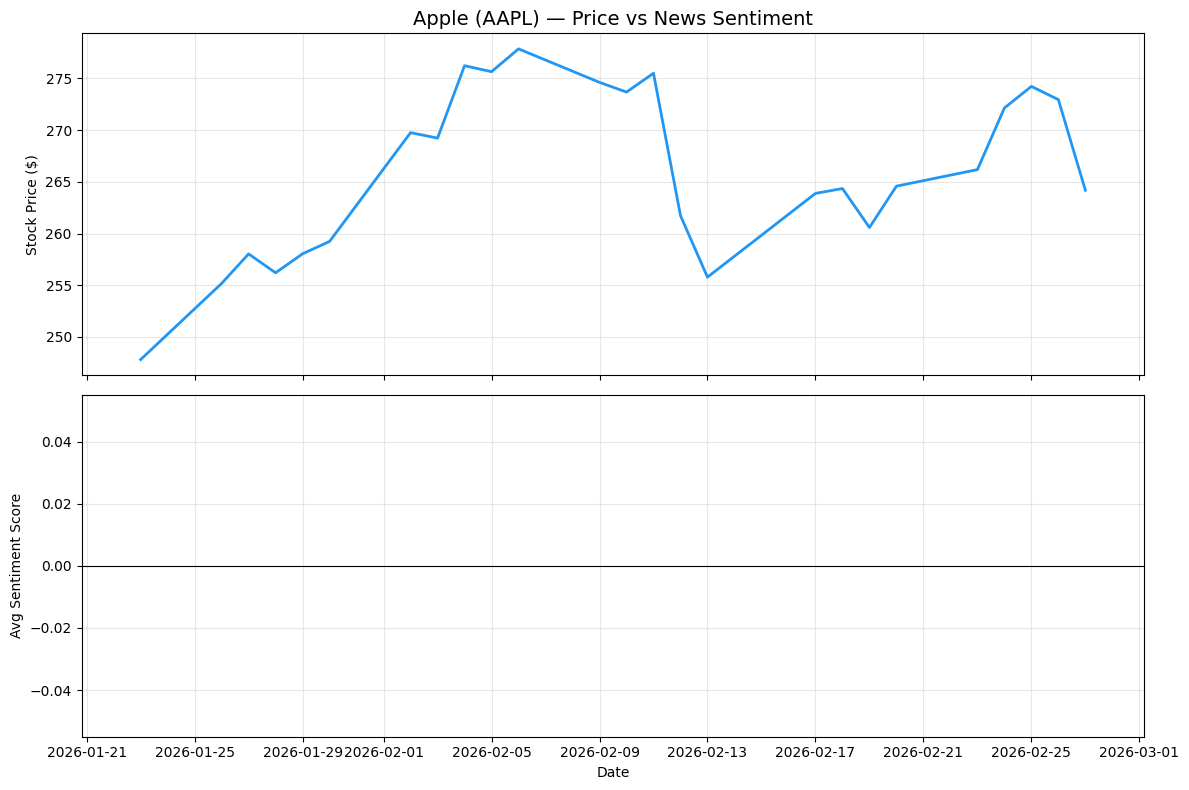


📊 Correlation (price change vs sentiment): nan
Fetching news for Tesla...


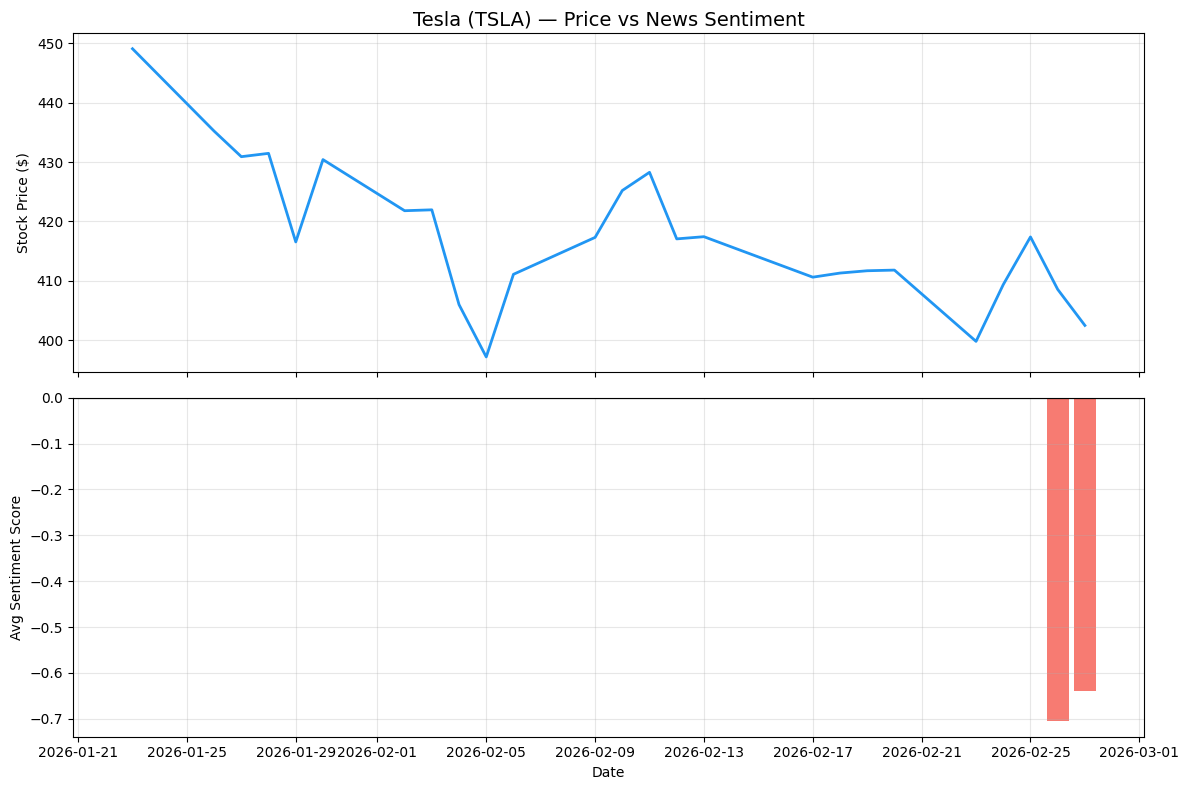


📊 Correlation (price change vs sentiment): 0.199


In [34]:
merged_aapl = plot_sentiment_vs_price('AAPL', 'Apple', days=25)
merged_tsla = plot_sentiment_vs_price('TSLA', 'Tesla', days=25)